# Noisy Fourier Analysis and Guided Initialization

Noisy version of the Fourier-guided initialization notebook. It starts with H2 only and evaluates the Fourier probes and VQE runs with a synthetic Aer estimator.


## Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.fourier import (
    analyze_fourier_line,
    build_fourier_problem,
    estimate_first_harmonic_guided_point,
    make_coordinate_direction,
    run_budget_comparison,
    run_vqe_reference_point,
    scan_harmonic_error,
    scan_spectral_profile,
    spectral_metrics,
)
from src.vqe.ansatz import build_ansatz
from src.vqe.molecular_system import statevector_grid_systems
from src.vqe.noise import SyntheticNoiseConfig, build_synthetic_noisy_aer_estimator
from src.visualization.fourier_plots import (
    plot_budget_comparison,
    plot_fourier_reconstruction,
    plot_harmonic_error,
    plot_harmonic_profile,
    plot_spectral_metrics,
    save_figure,
)

pd.set_option("display.max_columns", None)

output_dir = "outputs/figures/fourier_noisy"
seed = 137


## Noise Model and H2 Systems


In [2]:
noise_config = SyntheticNoiseConfig(
    shots=2048,
    seed_simulator=seed,
    single_qubit_depolarizing=0.001,
    two_qubit_depolarizing=0.01,
    readout_error=0.02,
)
noisy_estimator = build_synthetic_noisy_aer_estimator(**{
    "shots": noise_config.shots,
    "seed_simulator": noise_config.seed_simulator,
    "single_qubit_depolarizing": noise_config.single_qubit_depolarizing,
    "two_qubit_depolarizing": noise_config.two_qubit_depolarizing,
    "readout_error": noise_config.readout_error,
})

systems = [
    system
    for system in statevector_grid_systems(profile="pilot")
    if system.name == "H2"
]

ansatz_name = "real_amplitudes"
reps = 2
mapper = "jw"
z2symmetry_reduction = False
optimizer_name = "cobyla"
reference_max_iter = 100
theta_samples = 64

noise_config.metadata(), [(system.name, system.basis, system.distances) for system in systems]


({'noise_source': 'synthetic_depolarizing_readout',
  'noise_pipeline': 'aer_estimator_decomposed_ansatz_v1',
  'shots': 2048,
  'default_precision': 0.022097086912079608,
  'seed_simulator': 137,
  'single_qubit_depolarizing': 0.001,
  'two_qubit_depolarizing': 0.01,
  'readout_error': 0.02},
 [('H2', 'sto-3g', (0.5, 0.735, 1.0))])

## Noisy Fourier Reconstruction for H2


In [3]:
demo_system = systems[0]
demo_distance = demo_system.distances[1]

problem, qubit_op, constant_energy = build_fourier_problem(
    demo_system,
    demo_distance,
    mapper=mapper,
    z2symmetry_reduction=z2symmetry_reduction,
)
ansatz = build_ansatz(
    name=ansatz_name,
    num_qubits=qubit_op.num_qubits,
    reps=reps,
    num_particles=problem.num_particles,
    num_spatial_orbitals=problem.num_spatial_orbitals,
)

vqe_reference = run_vqe_reference_point(
    qubit_op=qubit_op,
    ansatz=ansatz,
    constant_energy=constant_energy,
    optimizer_name=optimizer_name,
    max_iter=reference_max_iter,
    seed=seed,
    estimator=noisy_estimator,
)

if not vqe_reference.get("success", False):
    raise RuntimeError(
        f"Noisy reference VQE failed: {vqe_reference.get('error_type')}: "
        f"{vqe_reference.get('error')}\n"
        f"Cause: {vqe_reference.get('error_cause')}"
    )

center = np.asarray(vqe_reference["optimal_params"], dtype=float)
direction = make_coordinate_direction(ansatz.num_parameters, parameter_index=0)
line = analyze_fourier_line(
    ansatz=ansatz,
    qubit_op=qubit_op,
    constant_energy=constant_energy,
    center=center,
    direction=direction,
    theta_samples=theta_samples,
    estimator=noisy_estimator,
)

spectral_metrics(line.coefficients)


{'r1': 0.9887401549512109, 'h_norm': 0.02759625166873039}

outputs/figures/fourier_noisy/noisy_fourier_reconstruction_h2.png


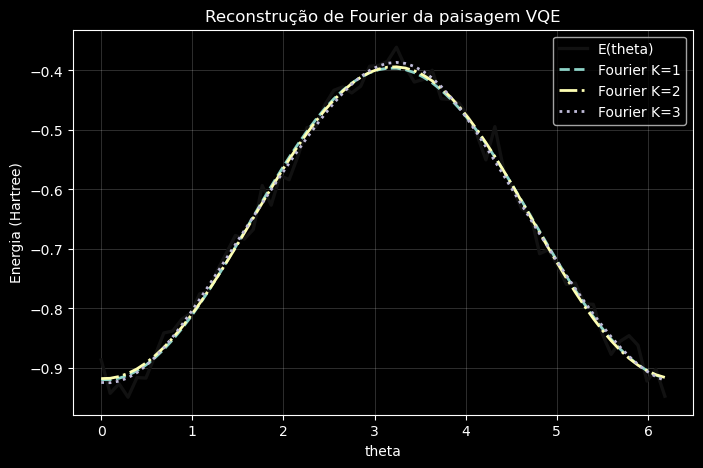

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_fourier_reconstruction(line, harmonic_orders=(1, 2, 3), ax=ax)
path = save_figure(fig, output_dir, "noisy_fourier_reconstruction_h2.png")
print(path)
plt.show()


## Noisy Guided Point


In [5]:
guided_point, guide_cost, guide_info = estimate_first_harmonic_guided_point(
    ansatz=ansatz,
    qubit_op=qubit_op,
    constant_energy=constant_energy,
    center=center,
    direction=direction,
    estimator=noisy_estimator,
)

pd.DataFrame([{
    "molecule": demo_system.name,
    "basis": demo_system.basis,
    "distance": demo_distance,
    "guide_cost": guide_cost,
    **guide_info,
}])


,molecule,basis,distance,guide_cost,a1,b1,theta_star,first_harmonic_amplitude
0,H2,sto-3g,0.735,3,-0.230571,-0.006775,0.029373,0.230671


## Noisy Spectral Profile


In [6]:
RUN_SPECTRAL_SCAN = True

if RUN_SPECTRAL_SCAN:
    spectral_df, profile_df = scan_spectral_profile(
        systems=systems,
        ansatz_name=ansatz_name,
        reps=reps,
        mapper=mapper,
        z2symmetry_reduction=z2symmetry_reduction,
        optimizer_name=optimizer_name,
        max_iter=reference_max_iter,
        theta_samples=theta_samples,
        seed=seed,
        global_samples=3,
        max_harmonics=8,
        estimator=noisy_estimator,
    )
    display(spectral_df.head())
    display(profile_df.head())


,molecule,basis,distance,regime,r1,h_norm
0,H2,sto-3g,0.500,local,0.986488,0.032001
1,H2,sto-3g,0.500,global,0.796034,0.271950
2,H2,sto-3g,0.500,global,0.956758,0.076084
3,H2,sto-3g,0.500,global,0.493987,0.493086
4,H2,sto-3g,0.735,local,0.992941,0.018231


,molecule,basis,distance,regime,k,normalized_amplitude
0,H2,sto-3g,0.5,local,1,0.640413
1,H2,sto-3g,0.5,local,2,0.004098
2,H2,sto-3g,0.5,local,3,0.005076
3,H2,sto-3g,0.5,local,4,0.019547
4,H2,sto-3g,0.5,local,5,0.015224


outputs/figures/fourier_noisy/noisy_fourier_harmonic_profile.png


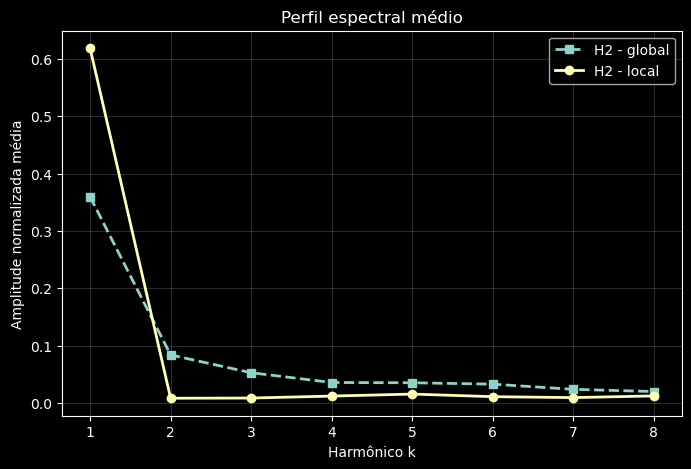

outputs/figures/fourier_noisy/noisy_fourier_spectral_metrics.png


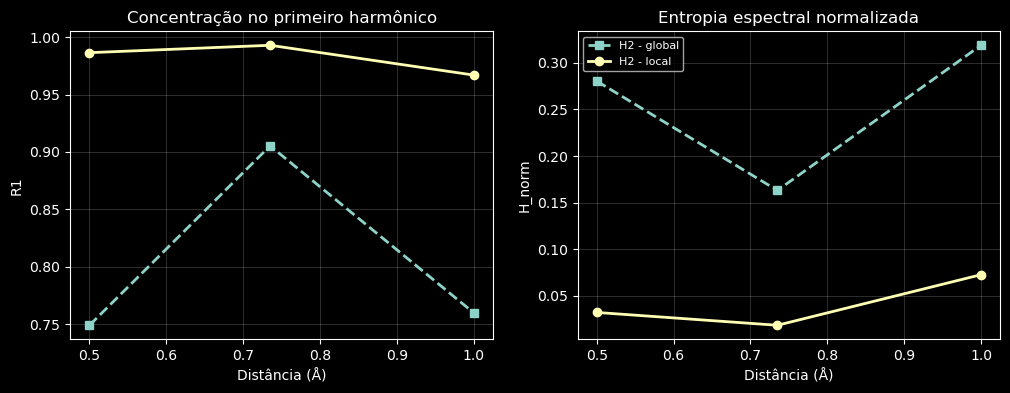

In [7]:
if RUN_SPECTRAL_SCAN:
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_harmonic_profile(profile_df, ax=ax)
    path = save_figure(fig, output_dir, "noisy_fourier_harmonic_profile.png")
    print(path)
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_spectral_metrics(spectral_df, ax=ax)
    path = save_figure(fig, output_dir, "noisy_fourier_spectral_metrics.png")
    print(path)
    plt.show()


## Noisy Error vs Harmonic Order


In [8]:
RUN_HARMONIC_ERROR = True

if RUN_HARMONIC_ERROR:
    harmonic_error_df = scan_harmonic_error(
        systems=systems,
        harmonic_grid=(1, 2, 3, 5),
        ansatz_name=ansatz_name,
        reps=reps,
        mapper=mapper,
        z2symmetry_reduction=z2symmetry_reduction,
        optimizer_name=optimizer_name,
        max_iter=reference_max_iter,
        theta_samples=theta_samples,
        seed=seed,
        estimator=noisy_estimator,
    )
    display(harmonic_error_df.head())


,molecule,basis,distance,K,rmse,delta_min_energy
0,H2,sto-3g,0.500,1,0.021461,0.022701
1,H2,sto-3g,0.500,2,0.021159,0.022701
2,H2,sto-3g,0.500,3,0.020965,0.022701
3,H2,sto-3g,0.500,5,0.020807,0.022701
4,H2,sto-3g,0.735,1,0.020649,0.000000


outputs/figures/fourier_noisy/noisy_fourier_error_vs_k.png


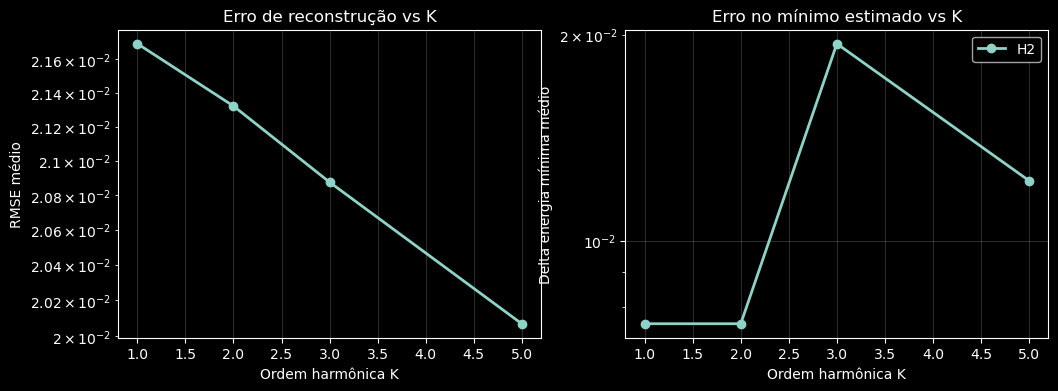

In [9]:
if RUN_HARMONIC_ERROR:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_harmonic_error(harmonic_error_df, ax=ax)
    path = save_figure(fig, output_dir, "noisy_fourier_error_vs_k.png")
    print(path)
    plt.show()


## Noisy Random vs Fourier-Guided Budget Comparison


In [10]:
RUN_BUDGET_COMPARISON = True

if RUN_BUDGET_COMPARISON:
    budget_df = run_budget_comparison(
        systems=systems,
        iteration_grid=(25, 50, 100),
        ansatz_name=ansatz_name,
        reps=reps,
        mapper=mapper,
        z2symmetry_reduction=z2symmetry_reduction,
        optimizer_name=optimizer_name,
        seed=seed,
        repeats=3,
        estimator=noisy_estimator,
    )

    budget_summary = (
        budget_df.groupby(["max_iter", "molecule", "mode"], as_index=False)
        .agg(mean_total_cost=("total_cost", "mean"), mean_abs_error=("abs_error", "mean"))
        .sort_values(["molecule", "max_iter", "mode"])
    )
    display(budget_summary)


,max_iter,molecule,mode,mean_total_cost,mean_abs_error
0,25,H2,fourier_guided,28.000000,0.316183
1,25,H2,random,25.000000,0.426409
2,50,H2,fourier_guided,53.000000,0.252224
3,50,H2,random,50.000000,0.330018
4,100,H2,fourier_guided,100.444444,0.320796
5,100,H2,random,99.000000,0.320205


outputs/figures/fourier_noisy/noisy_fourier_budget_comparison.png


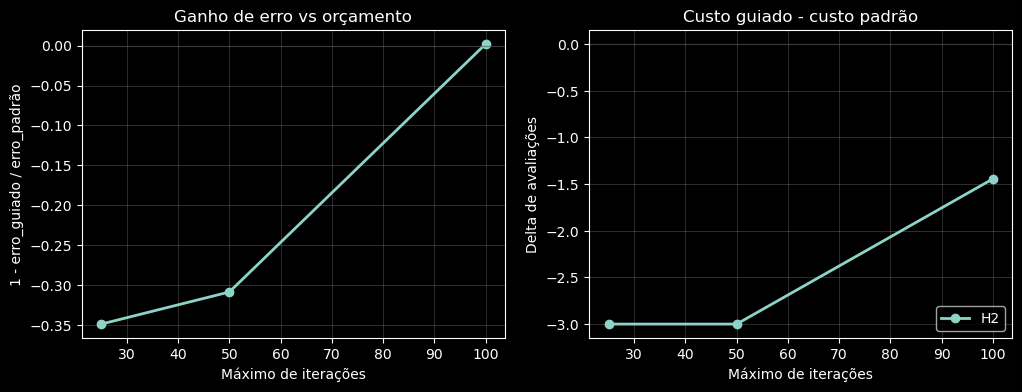

In [11]:
if RUN_BUDGET_COMPARISON:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    plot_budget_comparison(budget_df, ax=ax)
    path = save_figure(fig, output_dir, "noisy_fourier_budget_comparison.png")
    print(path)
    plt.show()
